In this notebook, we will match the latents obtained from the autoencoder with the corresponding text descriptors of the bacterial strains the compounds ara active against.

In [62]:
import numpy as np
import pandas as pd
import h5py, pickle
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np

# Load latents, bacterial descriptors and bioactivity data

In [2]:
f = '../../data/diffusion_training/latents_final_dataset.npy'
latents = np.load(f)
latents.shape

(179340, 300)

Text(0.5, 1.0, 'Distribution of values in the vector space')

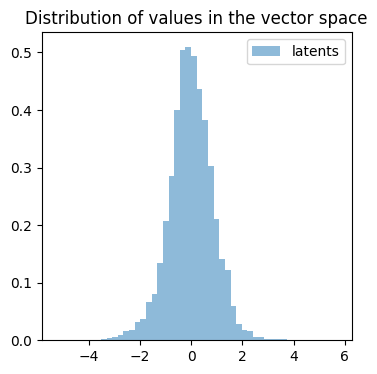

In [3]:
fig, ax = plt.subplots(figsize=(4,4))
plt.hist(latents.flatten()[:10000], bins=50, label='latents', density=True, alpha=0.5,)
ax.legend()
plt.title('Distribution of values in the vector space')

In [4]:
min(latents.flatten()), max(latents.flatten())

(np.float32(-8.427541), np.float32(11.969098))

In [5]:
# Latents need to be reshaped to match the original architecture from the LDMol publication (https://arxiv.org/abs/2405.17829)
latent_size = 127 # These parameters are from the LD model
in_channels = 64

if latents.shape[1:]!=(latent_size,in_channels):
    correct_shape = [latent_size,in_channels]
    m = f"Changing latent size from: {latents.shape} to : {correct_shape}"
    print(m)
    total_shape = latent_size*in_channels
    if latents.shape[-1]<total_shape:
        latents = np.pad(latents,((0,0),(0,total_shape-latents.shape[-1])))
    elif latents.shape[-1]>total_shape:
        latents = latents[:,:total_shape]
    m = "Reshaping"
    print(m)
    latents = np.reshape(latents,(latents.shape[0],latent_size,in_channels))
    m = "Reshaping Complete!"
    print(m)

Changing latent size from: (179340, 300) to : [127, 64]
Reshaping
Reshaping Complete!


In [6]:
f = '../../data/diffusion_training/smiles_final_dataset.csv'

latent_smiles = pd.read_csv(f).smiles.values
len(latent_smiles)

179340

In [7]:
latents_dict = dict(zip(latent_smiles, latents))

In [63]:
# Guidance (Bacterial descriptors)
with h5py.File('../../data/bacteria_embeddings.h5', 'r') as f:
    print(f.keys())
    embeddings = f['embeddings'][:]
    species = f['species'][:]
    species = np.array([s.decode('utf-8') for s in species])

<KeysViewHDF5 ['embeddings', 'species']>


In [64]:
embeddings.shape, species.shape

((843, 3072), (843,))

In [65]:
species_embs_dict = dict(zip(species, embeddings))

In [66]:
species_embs_dict

{np.str_('Abiotrophia defectiva'): array([-0.03489216,  0.04698991, -0.00544937, ...,  0.0118822 ,
        -0.00195847, -0.01268377], shape=(3072,)),
 np.str_('Acetobacter aceti'): array([-0.00392846,  0.03476578, -0.00960544, ...,  0.00323587,
        -0.00283991, -0.00221402], shape=(3072,)),
 np.str_('Achromobacter denitrificans'): array([-0.00881764,  0.03355496, -0.00648393, ...,  0.00920238,
         0.00650285, -0.02767653], shape=(3072,)),
 np.str_('Achromobacter ruhlandii'): array([-0.04030234,  0.02693511, -0.01035773, ...,  0.00608485,
         0.00724163, -0.01022606], shape=(3072,)),
 np.str_('Achromobacter xylosoxidans'): array([-0.03957001,  0.04925412, -0.00897312, ...,  0.00023751,
         0.00075236, -0.0323866 ], shape=(3072,)),
 np.str_('Acidipropionibacterium acidipropionici'): array([-0.038973  ,  0.04945738, -0.01069528, ...,  0.00286362,
        -0.00709805, -0.01230409], shape=(3072,)),
 np.str_('Acidovorax temperans'): array([-0.04415848,  0.02472074, -0.0084

In [48]:
# Activity
activity = pd.read_csv('../../data/figures_source_data/binary_activity_matrix_chembl.csv')
activity.head(2)


,smiles,acinetobacterbaumannii,acinetobacterbaylyi,acinetobactercalcoaceticus,acinetobactercalcoaceticussubsp.anitratus,acinetobacterhaemolyticus,acinetobacterlwoffii,acinetobacterpittii,actinomycesisraelii,actinomycesnaeslundii,...,vibrioparahaemolyticus,vibriosplendidus,vibriovulnificus,xanthomonasaxonopodis,xanthomonascampestris,xanthomonasoryzae,xanthomonasvesicatoria,yersiniaenterocolitica,yersiniapestis,yersiniapseudotuberculosis
0,BrC1[C@@H](c2c[nH]c3ccccc23)c2[nH]c3ccccc3c2[C...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,BrCCCCCOCc1c(-c2ccccc2)nc2sc3ccccc3n12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
activity.smiles.nunique()

46066

In [49]:
# remove smiles column
activity = activity[~np.all(activity.iloc[:,1:] == 0, axis=1)]

In [50]:
activity.shape

(46066, 274)

In [51]:
activity.smiles.unique().shape

(46066,)

In [52]:
activity = activity.dropna(subset=['smiles'])
activity.shape

(46066, 274)

In [53]:
activity.smiles.unique().shape

(46066,)

In [24]:
len(set(activity.smiles.unique()) - set(list(latents_dict)))

5011

In [54]:
# Map abbreviations to full names
bacterial_names = pd.read_csv("../../data/bacteria_long_names.csv")
code2name = dict(zip(bacterial_names['pathogen_code'], bacterial_names['search_text']))

In [55]:
species_chembl = [code2name[sp] for sp in activity.columns[1:]]
len(species_chembl)

273

In [60]:
for s in activity.columns[1:]:
    guid_vector = species_embs_dict[code2name[s]]
    guid_vector = np.vstack([guid_vector,guid_vector])
    # np.save(s+'.npy', guid_vector) # save guidance vectors for later use
# Add M abscessus as well
guid_vector = species_embs_dict['Mycobacteroides abscessus']
guid_vector = np.vstack([guid_vector,guid_vector])
# np.save('mycobacteroidesabscessus.npy', guid_vector)

# Match latents with species embeddings (guidance)

In [28]:
## Save correspondence from smiles to latent and to the different guidances (to later do random sampling to avoid overrepresentation)
from collections import defaultdict

# Pre-group species by SMILES
species_cols = activity.columns[1:]
smiles_to_species = {
    row['smiles']: [species for species in species_cols if row[species] == 1]
    for _, row in activity.iterrows()
}

latent_to_guidance = defaultdict(list)
smiles2species = defaultdict(list)

for sm, species_array in tqdm(smiles_to_species.items()):
    if sm not in latents_dict:
        continue
    latent = latents_dict[sm]
    for sp in species_array:
        sp_name = code2name[sp]
        latent_to_guidance[sm].append(species_embs_dict[sp_name])
        smiles2species[sm].append(sp_name)

100%|██████████| 46066/46066 [00:00<00:00, 299495.62it/s]


In [29]:
len(smiles_to_species)

46066

In [30]:
len(latent_to_guidance)

41055

In [31]:
# OPTIONAL: Save
# sys.exit()
# import pickle
# with open('/aloy/home/grojas/tesis/antibiotics/final_pipeline/antibiotic_design/LDMOL/repeat_data_no_percentiles/latents_all_species/smiles2guidance.pkl', 'wb') as f:
#     pickle.dump(latent_to_guidance, f)

# with open('/aloy/home/grojas/tesis/antibiotics/final_pipeline/antibiotic_design/LDMOL/repeat_data_no_percentiles/latents_all_species/smiles2latent.pkl', 'wb') as f:
#     pickle.dump(latents_dict, f)

# with open('/aloy/home/grojas/tesis/antibiotics/final_pipeline/antibiotic_design/LDMOL/repeat_data_no_percentiles/latents_all_species/smiles2species.pkl', 'wb') as f:
#     pickle.dump(smiles2species, f)


In [32]:
latent_to_guidance['Brc1c(-c2ccc(-c3[nH]c4cc(C5=NCCN5)ccc4c3Br)cc2)[nH]c2cc(C3=NCCN3)ccc12']

[array([-0.0060172 ,  0.00426181, -0.0140908 , ...,  0.00127258,
        -0.00377304, -0.00903623], shape=(3072,)),
 array([-0.04255594,  0.01990101, -0.01209389, ...,  0.00825528,
        -0.00359504, -0.00228141], shape=(3072,)),
 array([-0.02597349, -0.00830778, -0.01028555, ...,  0.01857583,
        -0.00575536,  0.0011588 ], shape=(3072,)),
 array([-0.06678095,  0.01556871, -0.01738242, ...,  0.01995092,
         0.00656206,  0.01341702], shape=(3072,)),
 array([-0.03017687,  0.00188605, -0.01315894, ...,  0.01493264,
         0.00093704,  0.0134226 ], shape=(3072,))]

In [33]:
smiles2species

defaultdict(list,
            {'BrC1[C@@H](c2c[nH]c3ccccc23)c2[nH]c3ccccc3c2[C@@H]1c1c[nH]c2ccccc12': ['Staphylococcus aureus'],
             'BrCCCCCOCc1c(-c2ccccc2)nc2sc3ccccc3n12': ['Bacillus subtilis'],
             'BrCCCOCc1c(-c2ccccc2)nc2sc3ccccc3n12': ['Bacillus subtilis',
              'Shigella dysenteriae'],
             'Brc1c(-c2ccc(-c3[nH]c4cc(C5=NCCN5)ccc4c3Br)cc2)[nH]c2cc(C3=NCCN3)ccc12': ['Bacillus anthracis',
              'Enterococcus faecalis',
              'Escherichia coli',
              'Pseudomonas aeruginosa',
              'Staphylococcus aureus'],
             'Brc1c(-c2ccc3c(c2)OCO3)nc2ncccn12': ['Mycobacterium tuberculosis'],
             'Brc1c(-c2ccccc2)nc2sc(Cc3noc4ccccc34)nn12': ['Bacillus subtilis',
              'Escherichia coli',
              'Pseudomonas aeruginosa',
              'Staphylococcus aureus'],
             'Brc1c[nH]nc1-c1nc(-c2ccc(Oc3ccccc3)cc2)no1': ['Staphylococcus aureus'],
             'Brc1cc(-c2nnc(-c3cc(Br)c(Br)[nH]3)o2)[nH

In [34]:
species_embs_dict['Escherichia coli'].shape

(3072,)

In [74]:
training_latents = []
training_guidance = []
training_smiles = []
training_bugnames = []

for sm, guidance_list in latent_to_guidance.items():
    latent = latents_dict[sm]  # the latent vector
    for guidance in guidance_list:
        training_latents.append(latent)
        training_guidance.append(guidance)
        training_smiles.append(sm)
    training_bugnames+=smiles2species[sm]

# Convert to arrays at once
training_latents = np.array(training_latents)
training_guidance = np.array(training_guidance)

training_latents.shape, training_guidance.shape, len(training_smiles), len(training_bugnames)

((57939, 127, 64), (57939, 3072), 57939, 57939)

In [71]:
# shuffle so not the same latents with different guides are seen sequencially
from sklearn.utils import shuffle
training_latents, training_guidance, training_smiles = shuffle(training_latents, training_guidance, training_smiles, random_state=42)

In [43]:
# Save np arrays
# sys.exit()
np.save("../../data/diffusion_training/matched_guidance_vectors_al_species.npy", training_guidance)
np.save("../../data/diffusion_training/matched_latents_all_species.npy", training_latents)

In [44]:
# Count unique guidance vectors
unique_guidance_vectors = np.unique(training_guidance, axis=0)
print("Number of unique guidance vectors:", unique_guidance_vectors.shape[0])

Number of unique guidance vectors: 43


## Stats

In [45]:
from collections import Counter

In [46]:
species_in_training_count = Counter(training_smiles)

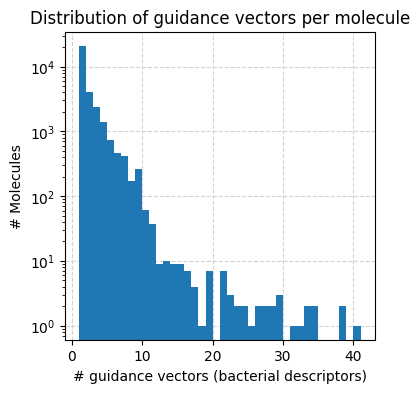

In [47]:
import matplotlib.pyplot as plt

# Plot histogram of counts
plt.figure(figsize=(4, 4))
plt.hist(species_in_training_count.values(), bins='auto', zorder=2)
plt.xlabel("# guidance vectors (bacterial descriptors)")
plt.ylabel("# Molecules")
plt.title("Distribution of guidance vectors per molecule")
plt.yscale("log")
plt.grid(zorder=0, ls='--', color='lightgrey')
plt.show()


In [48]:
min(species_in_training_count.values()), max(species_in_training_count.values())

(1, 41)

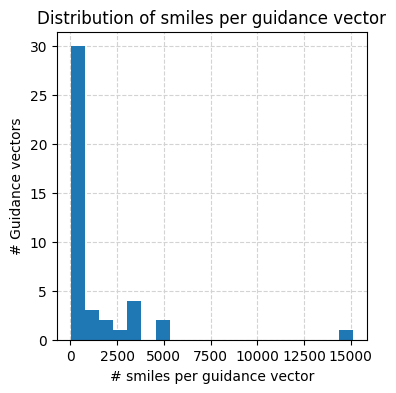

In [77]:
# training_bugnames = [item for sublist in training_bugnames for item in sublist]
smiles_per_species_count = Counter(training_bugnames)
# import matplotlib.pyplot as plt

# Plot histogram of counts
plt.figure(figsize=(4, 4))
plt.hist(smiles_per_species_count.values(), bins=20, zorder=2)
# plt.yticks(np.arange(0,12,2))
plt.xlabel("# smiles per guidance vector")
plt.ylabel("# Guidance vectors")
plt.title("Distribution of smiles per guidance vector")
plt.grid(ls='--', color='lightgray', zorder=0)
# plt.xscale("log")
plt.show()

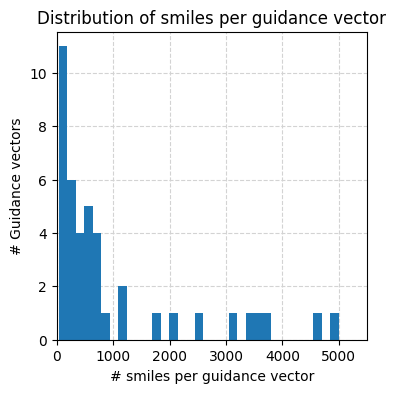

In [82]:
# training_bugnames = [item for sublist in training_bugnames for item in sublist]
smiles_per_species_count = Counter(training_bugnames)
# import matplotlib.pyplot as plt

# Plot histogram of counts
plt.figure(figsize=(4, 4))
plt.hist(smiles_per_species_count.values(), bins=100, zorder=2)
# plt.yticks(np.arange(0,12,2))
plt.xlabel("# smiles per guidance vector")
plt.ylabel("# Guidance vectors")
plt.title("Distribution of smiles per guidance vector")
plt.grid(ls='--', color='lightgray', zorder=0)
# plt.xscale("log")
plt.xlim(0,5500)
plt.show()

In [83]:
min(smiles_per_species_count.values()), max(smiles_per_species_count.values())

(29, 15107)

/aloy/home/grojas/anaconda3/envs/ersilia/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(150.22222222222223, 0.5, 'Molecules')

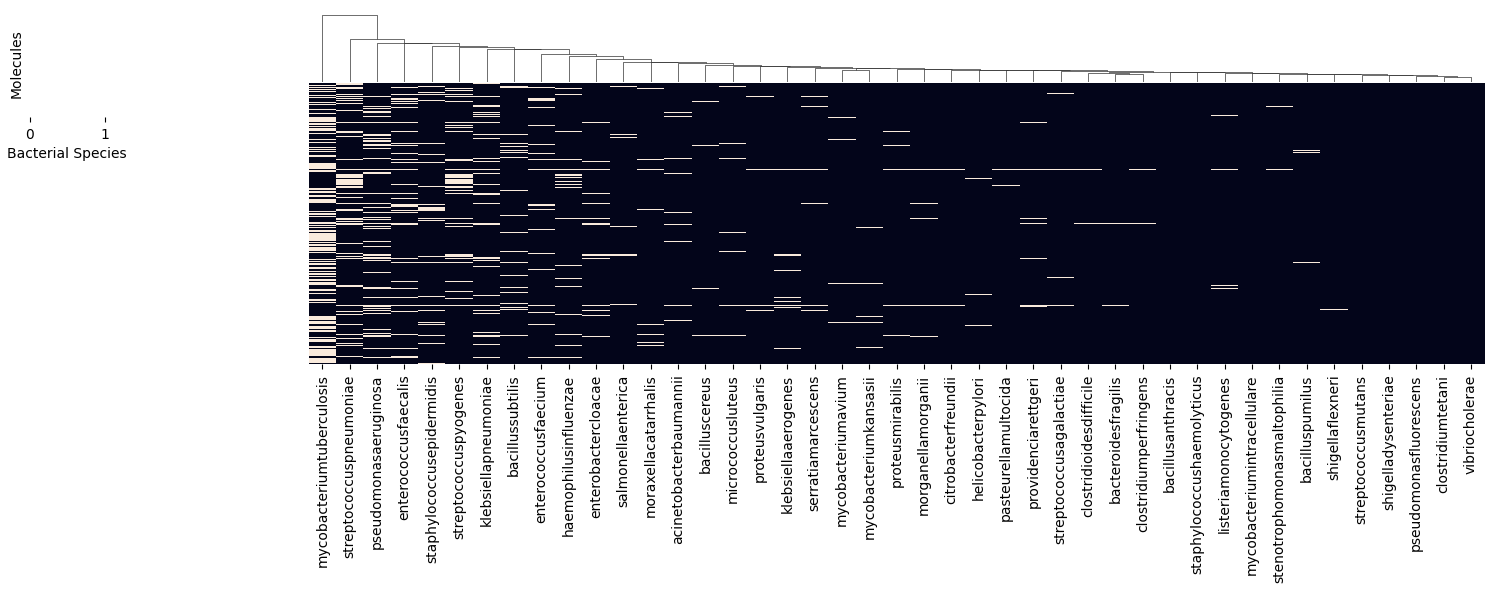

In [91]:
import seaborn as sns
sns.clustermap(activity.iloc[:,1:].astype(float), cbar=False,row_cluster=False,yticklabels=False, figsize=(15,6))
plt.yticks([])  
plt.xlabel('Bacterial Species')
plt.ylabel('Molecules')

In [88]:
min(activity.iloc[:,1:].sum())

29.0

In [89]:
max(activity.iloc[:,1:].sum())

15441.0

In [90]:
min(activity.iloc[:,1:].sum(axis=1)), max(activity.iloc[:,1:].sum(axis=1))

(1.0, 41.0)